## 📦 ISSUE 1 — Carga y Primera Exploración del Dataset
### **Proyecto:** Clasificación — Bank Marketing  
### **Dataset:** [Bank Marketing - UCI ML Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
### **Objetivo:** Predecir cual perfil de cliente presenta mayor probabilidad a suscribir un depósito a plazo fijo (`y` = Alta probabilidad, Media y Baja), para reducir costes de las campañas de marketing.
---
### 🎯 ¿Por qué este dataset?
### El dataset Bank Marketing recoge datos reales de campañas de marketing telefónico de un banco portugués.  
### Es un problema de **clasificación**: queremos predecir cual perfil de cliente presenta mayor probabilidad a contratar un depósito a plazo.  
### Tiene 45.211 registros y 16 variables de entrada, lo que lo hace suficientemente grande para entrenar modelos robustos.
---

### **1.1 Cargar dataset y importar librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df= pd.read_csv("../data/raw/bank-full.csv", sep= ";")

### **1.2 Visualizar dataFrame y tipos de datos**

In [3]:
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [5]:
df.shape

(45211, 17)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [7]:
print('📋 Tipos de datos por columna:\n')
info_columnas = pd.DataFrame({
    'Tipo de dato'   : df.dtypes,
    'Valores únicos' : df.nunique(),
    'Ejemplo valor'  : df.iloc[0]
})
display(info_columnas)
print(f'\n📌 Columnas numéricas  : {list(df.select_dtypes(include=["int64", "float64"]).columns)}')
print(f'📌 Columnas categóricas: {list(df.select_dtypes(include=["str"]).columns)}')

📋 Tipos de datos por columna:



,Tipo de dato,Valores únicos,Ejemplo valor
age,int64,77,58
job,str,12,management
marital,str,3,married
education,str,4,tertiary
default,str,2,no
balance,int64,7168,2143
housing,str,2,yes
loan,str,2,no
contact,str,3,unknown
day,int64,31,5



📌 Columnas numéricas  : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
📌 Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df.select_dtypes(include='str').describe()


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [11]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [21]:
# ── Nulos encubiertos como 'unknown' ───────────────────────
print("🔍 Frecuencia del valor 'unknown' en columnas categóricas:\n")
cols_categoricas = df.select_dtypes(include='str').columns
unknown_counts = {}
for col in cols_categoricas:
    n_unknown = (df[col] == 'unknown').sum()
    pct = round(n_unknown / len(df) * 100, 2)
    if n_unknown > 0:
        unknown_counts[col] = {'Cantidad unknown': n_unknown, '% del total': pct}
if unknown_counts:
    display(pd.DataFrame(unknown_counts).T.sort_values('Cantidad unknown', ascending=False))
    print("\n⚠️ Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.")
else:
    print("✅ No se encontraron valores 'unknown' en columnas categóricas.")

🔍 Frecuencia del valor 'unknown' en columnas categóricas:



,Cantidad unknown,% del total
poutcome,36959.0,81.75
contact,13020.0,28.80
education,1857.0,4.11
job,288.0,0.64



⚠️ Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.


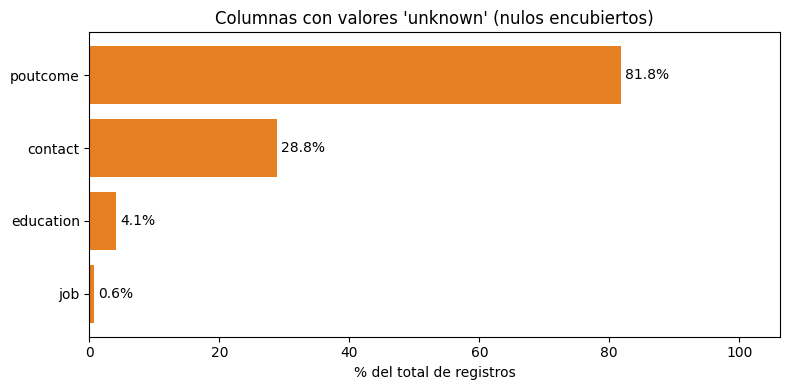

In [25]:
# ── Visualización de nulos/unknowns ────────────────────────
if unknown_counts:
    unk_df = pd.DataFrame(unknown_counts).T.reset_index()
    unk_df.columns = ['Columna', 'Cantidad', 'Porcentaje']
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(unk_df['Columna'], unk_df['Porcentaje'], color='#e67e22')
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in unk_df['Porcentaje']], padding=3)
    ax.set_xlabel('% del total de registros')
    ax.set_title("Columnas con valores 'unknown' (nulos encubiertos)")
    ax.set_xlim(0, unk_df['Porcentaje'].max() * 1.3)
    plt.tight_layout()
    plt.show()

In [26]:
n_duplicados = df.duplicated().sum()
pct_duplicados = round(n_duplicados / len(df) * 100, 2)
print('=' * 45)
print('  🔍 ANÁLISIS DE DUPLICADOS')
print('=' * 45)
print(f'  Filas duplicadas : {n_duplicados:,}')
print(f'  % del total      : {pct_duplicados}%')
print('=' * 45)
if n_duplicados > 0:
    print('\n⚠️ Se encontraron filas duplicadas. Ejemplo:')
    display(df[df.duplicated(keep=False)].head(6))
    print('\n→ Acción recomendada: eliminar duplicados en el preprocesamiento con df.drop_duplicates()')
else:
    print('\n✅ No hay filas duplicadas en el dataset.')

  🔍 ANÁLISIS DE DUPLICADOS
  Filas duplicadas : 0
  % del total      : 0.0%

✅ No hay filas duplicadas en el dataset.
